<a href="https://colab.research.google.com/github/a1s2d2f36g6g6q1/ComputerVision/blob/main/Assignment2_2021041094%EC%84%9C%EB%8F%99%EC%9A%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
#1. 라이브러리
import cv2
import numpy as np
import matplotlib.pyplot as plt

# HW 2-1

--2025-04-13 05:02:14--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 589115 (575K) [image/tiff]
Saving to: ‘washed_out.tif’

washed_out.tif      100%[===================>] 575.31K  --.-KB/s    in 0.05s   

2025-04-13 05:02:14 (10.6 MB/s) - ‘washed_out.tif’ saved [589115/589115]



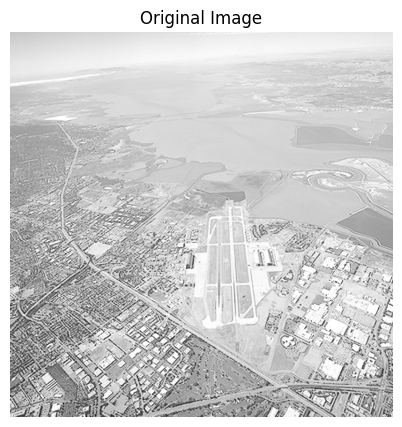

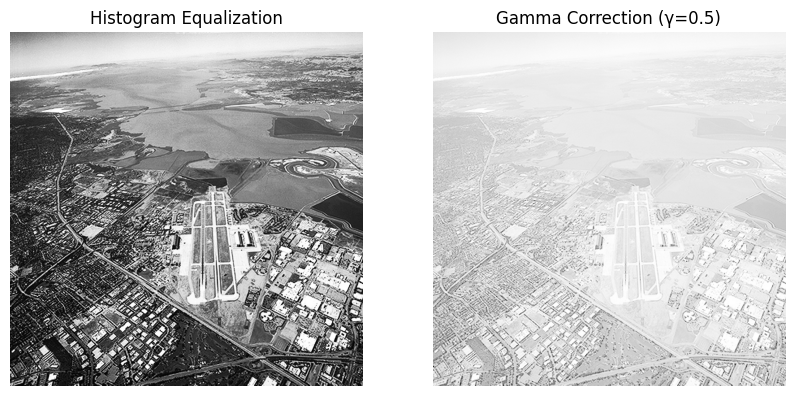

In [47]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif" -O washed_out.tif
img = cv2.imread('washed_out.tif', cv2.IMREAD_GRAYSCALE)

# 2. 원본 영상 출력
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# 3. 히스토그램 평활화
img_equalized = cv2.equalizeHist(img)

# 4. 감마 변환
gamma = 0.5
gamma_corrected = np.array(255 * (img / 255) ** gamma, dtype=np.uint8)

# 5. 결과 영상 출력
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_equalized, cmap='gray')
axes[0].set_title('Histogram Equalization')
axes[0].axis('off')

axes[1].imshow(gamma_corrected, cmap='gray')
axes[1].set_title(f'Gamma Correction (γ={gamma})')
axes[1].axis('off')

plt.show()

# 분석:
# - 히스토그램 평활화: 전체 밝기 분포를 확장하여 대비 향상
# - 감마 보정: 밝은 영역 강조, 대비 개선

# HW 2-2

--2025-04-13 05:02:15--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791311 (773K) [image/tiff]
Saving to: ‘pollen.tif’

pollen.tif          100%[===================>] 772.76K  --.-KB/s    in 0.06s   

2025-04-13 05:02:15 (12.9 MB/s) - ‘pollen.tif’ saved [791311/791311]



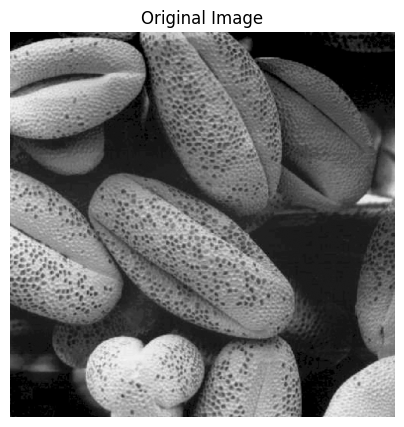

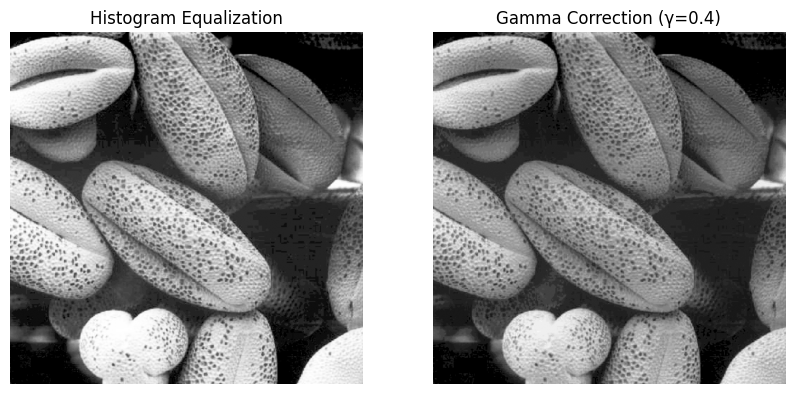

In [48]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif" -O pollen.tif
img = cv2.imread('pollen.tif', cv2.IMREAD_GRAYSCALE)

# 2. 원본 영상 출력
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# 3. 히스토그램 평활화
equalized = cv2.equalizeHist(img)

# 4. 감마 보정
gamma = 0.4
gamma_corrected = np.array(255 * (img / 255) ** gamma, dtype=np.uint8)

# 5. 결과 영상 출력
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(equalized, cmap='gray')
axes[0].set_title('Histogram Equalization')
axes[0].axis('off')

axes[1].imshow(gamma_corrected, cmap='gray')
axes[1].set_title(f'Gamma Correction (γ={gamma})')
axes[1].axis('off')

plt.show()

# 분석:
# 2-1 의 경우 원본이 저대비 영역이 커 개선 효과가 크게 있었으나
# 2-2 의 경우 초기 상태가 상대적으로 양호하여 평활화 / 보정 효과가 적은 영역에만 나타남

# HW 2-3

--2025-04-13 05:02:16--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 360574 (352K) [image/tiff]
Saving to: ‘rice.tif’

rice.tif            100%[===================>] 352.12K  --.-KB/s    in 0.04s   

2025-04-13 05:02:17 (8.99 MB/s) - ‘rice.tif’ saved [360574/360574]



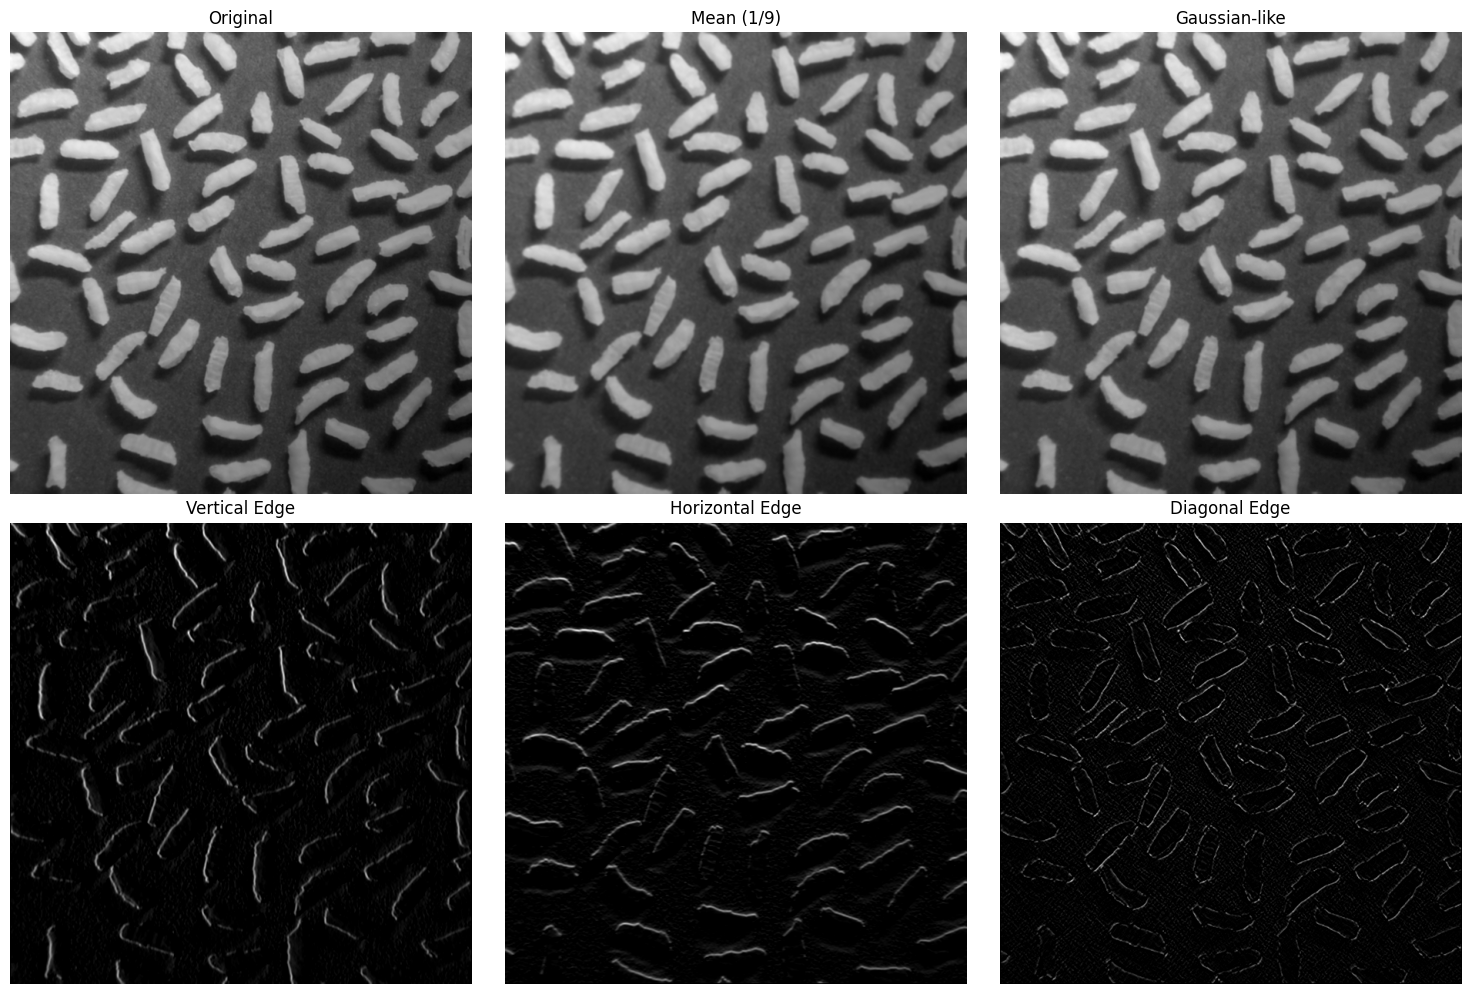

In [49]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif" -O rice.tif
img = cv2.imread('rice.tif', cv2.IMREAD_GRAYSCALE)

# 2. 마스크
masks = {
    'Mean (1/9)': np.ones((3,3), dtype=np.float32) / 9,

    'Gaussian-like': np.array([
        [0.0030, 0.0133, 0.0219],
        [0.0133, 0.0596, 0.0983],
        [0.0219, 0.0983, 0.1621]
    ], dtype=np.float32),

    'Vertical Edge': np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32),

    'Horizontal Edge': np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ], dtype=np.float32),

    'Diagonal Edge': np.array([
        [ 1,  0, -1],
        [ 0,  0,  0],
        [-1,  0,  1]
    ], dtype=np.float32)
}

# 3. 필터
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, (name, kernel) in enumerate(masks.items(), start=1):
    result = cv2.filter2D(img, -1, kernel)
    axes[i].imshow(result, cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 분석:
# - 평균 필터 -> 전체적으로 흐려지는 느낌. 경계도 같이 뭉개짐
# - 가우시안 필터 -> 부드럽게 정리되지만 중심은 좀 더 또렷함
# - 수직 에지 필터 -> 세로 경계가 잘 보이고 나머지는 흐릿함
# - 수평 에지 필터 -> 가로 방향 구조가 눈에 띄게 나옴
# - 대각선 필터 -> 비스듬한 방향만 강조돼서 독특한 느낌

# 요약:
# - 블러 필터 -> 전체를 부드럽게 만들고
# - 에지 필터 -> 경계를 더 뚜렷하게 만듦

# HW 2-4

--2025-04-13 05:02:18--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/school.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824868 (806K) [image/jpeg]
Saving to: ‘school.jpg’

school.jpg          100%[===================>] 805.54K  --.-KB/s    in 0.06s   

2025-04-13 05:02:18 (14.1 MB/s) - ‘school.jpg’ saved [824868/824868]



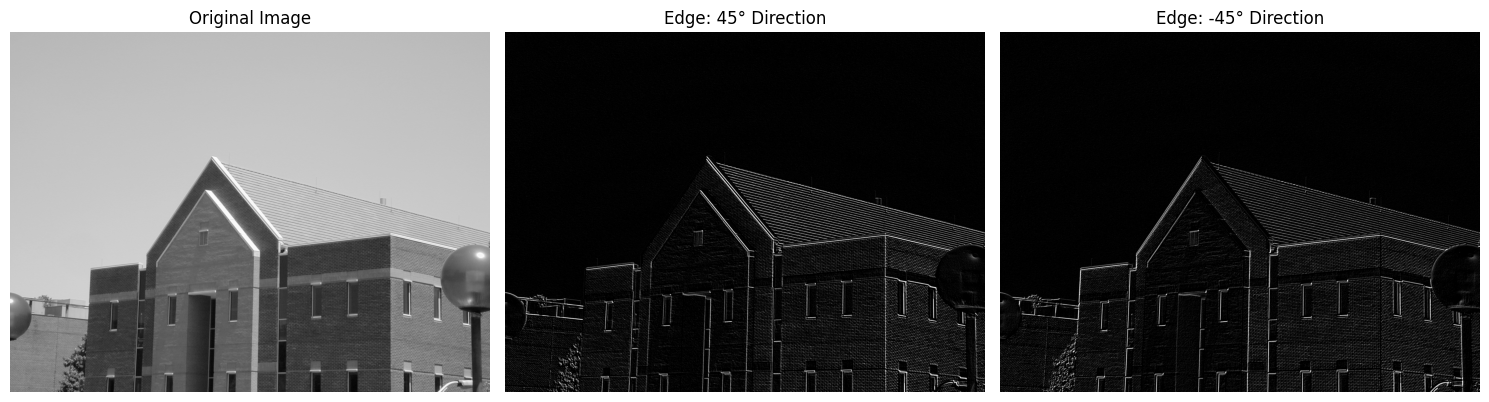

In [50]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/school.jpg" -O school.jpg
img = cv2.imread('school.jpg', cv2.IMREAD_GRAYSCALE)

# 2. 마스크
sobel_45 = np.array([
    [0, 1, 2],
    [-1, 0, 1],
    [-2, -1, 0]
], dtype=np.float32)

sobel_neg45 = np.array([
    [2, 1, 0],
    [1, 0, -1],
    [0, -1, -2]
], dtype=np.float32)

# 3. 필터
edge_45 = cv2.filter2D(img, -1, sobel_45)
edge_neg45 = cv2.filter2D(img, -1, sobel_neg45)

# 4. 결과
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(edge_45, cmap='gray')
axes[1].set_title('Edge: 45° Direction')
axes[1].axis('off')

axes[2].imshow(edge_neg45, cmap='gray')
axes[2].set_title('Edge: -45° Direction')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# HW 2-5

--2025-04-13 05:02:20--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/finger.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 73452 (72K) [image/jpeg]
Saving to: ‘finger.jpg’

finger.jpg          100%[===================>]  71.73K  --.-KB/s    in 0.02s   

2025-04-13 05:02:20 (3.03 MB/s) - ‘finger.jpg’ saved [73452/73452]



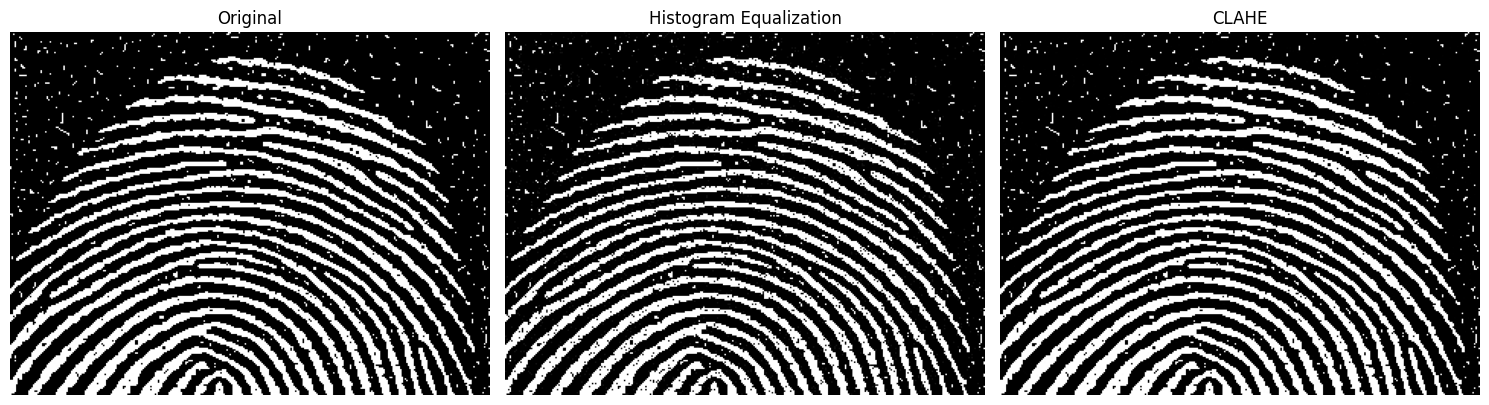

In [51]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/finger.jpg" -O finger.jpg
img = cv2.imread('finger.jpg', cv2.IMREAD_GRAYSCALE)

# 2. 히스토그램 평활화
hist_eq = cv2.equalizeHist(img)

# 3. CLAHE (더 좋은 방법?)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(img)

# 4. 결과
import matplotlib.pyplot as plt

images = [img, hist_eq, clahe_img]
titles = ['Original', 'Histogram Equalization', 'CLAHE']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 분석:
# - 히스토그램 평활화는 대비는 올라가지만 선이 날아가는 부분 있음
# - CLAHE는 지역적 밝기 조절로 지문 선이 더 또렷하게 보여서 더 좋은 방법이 아닐까 싶음

# HW 2-6

--2025-04-13 05:02:20--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0905(a)(wirebond-mask).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30092 (29K) [image/tiff]
Saving to: ‘wirebond.tif’

wirebond.tif        100%[===================>]  29.39K  --.-KB/s    in 0.003s  

2025-04-13 05:02:20 (8.35 MB/s) - ‘wirebond.tif’ saved [30092/30092]



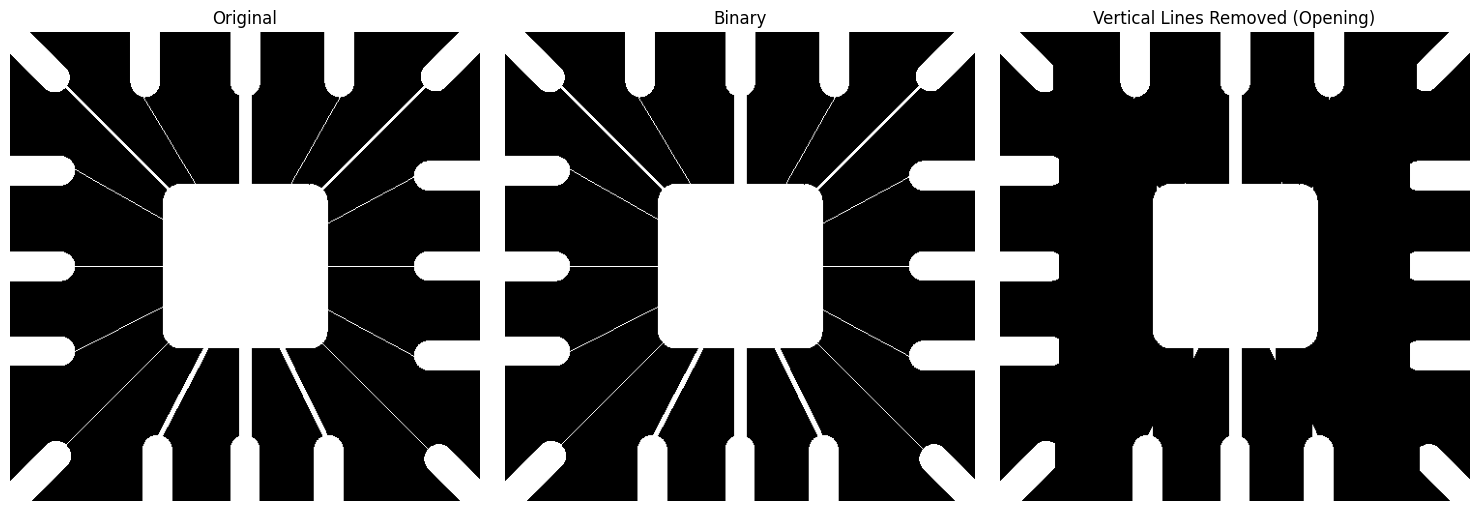

In [52]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0905(a)(wirebond-mask).tif" -O wirebond.tif
img = cv2.imread('wirebond.tif', cv2.IMREAD_GRAYSCALE)

# 2. 이진화
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Morphological Opening 얇은 수직선 제거용
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 4. 결과
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Original', 'Binary', 'Vertical Lines Removed (Opening)']
images = [img, binary, opened]

for i in range(3):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 분석:
# - 수직 방향 선이 커널 형태와 일치하므로 opening에 의해 제거됨
# - 커널 크기는 제거하고자 하는 선 길이에 따라 조절

# HW 2-7

--2025-04-13 05:02:21--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0939(a)(headCT-Vandy).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262750 (257K) [image/tiff]
Saving to: ‘head.tif’

head.tif            100%[===================>] 256.59K  --.-KB/s    in 0.04s   

2025-04-13 05:02:21 (6.75 MB/s) - ‘head.tif’ saved [262750/262750]



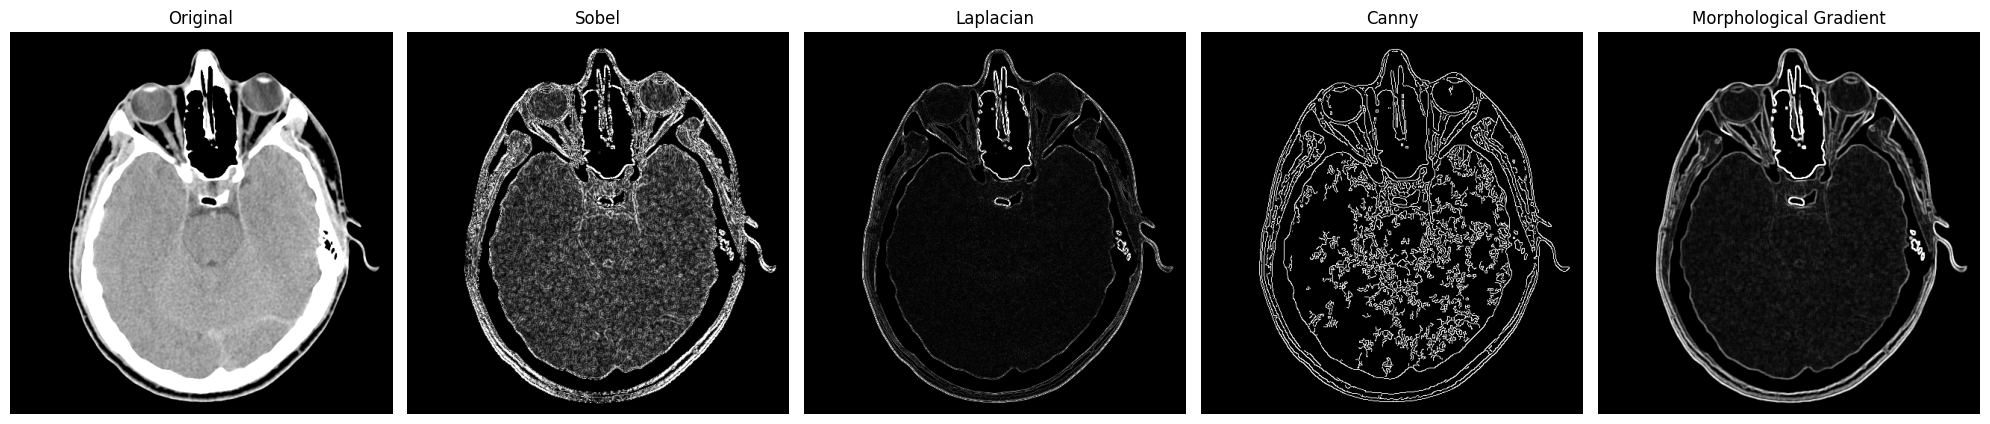

In [53]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0939(a)(headCT-Vandy).tif" -O head.tif
img = cv2.imread('head.tif', cv2.IMREAD_GRAYSCALE)


# 2. Sobel (x + y)
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.convertScaleAbs(sobel_x) + cv2.convertScaleAbs(sobel_y)

# 3. Laplacian
lap = cv2.Laplacian(img, cv2.CV_64F)
lap = cv2.convertScaleAbs(lap)

# 4. Canny
canny = cv2.Canny(img, 50, 150)

# 5. Morphological Gradient
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
morph_grad = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

# 6. 출력
import matplotlib.pyplot as plt

titles = ['Original', 'Sobel', 'Laplacian', 'Canny', 'Morphological Gradient']
images = [img, sobel, lap, canny, morph_grad]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 분석:
# - Sobel: 뼈 테두리와 큰 구조 경계가 부드럽게 잘 드러남
# - Laplacian: 전체적으로 강한 경계를 잘 잡지만 노이즈가 같이 포함됨
# - Canny: 윤곽이 날카롭고 세밀하게 표현되어 구조가 명확해짐
# - Morphological Gradient: 외곽선 중심으로 구조가 강조되지만 미세한 디테일은 덜함

# HW 2-9

--2025-04-13 05:02:22--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0938(a)(cygnusloop_Xray_original).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 321002 (313K) [image/tiff]
Saving to: ‘xray.tif’

xray.tif            100%[===================>] 313.48K  --.-KB/s    in 0.04s   

2025-04-13 05:02:22 (7.01 MB/s) - ‘xray.tif’ saved [321002/321002]



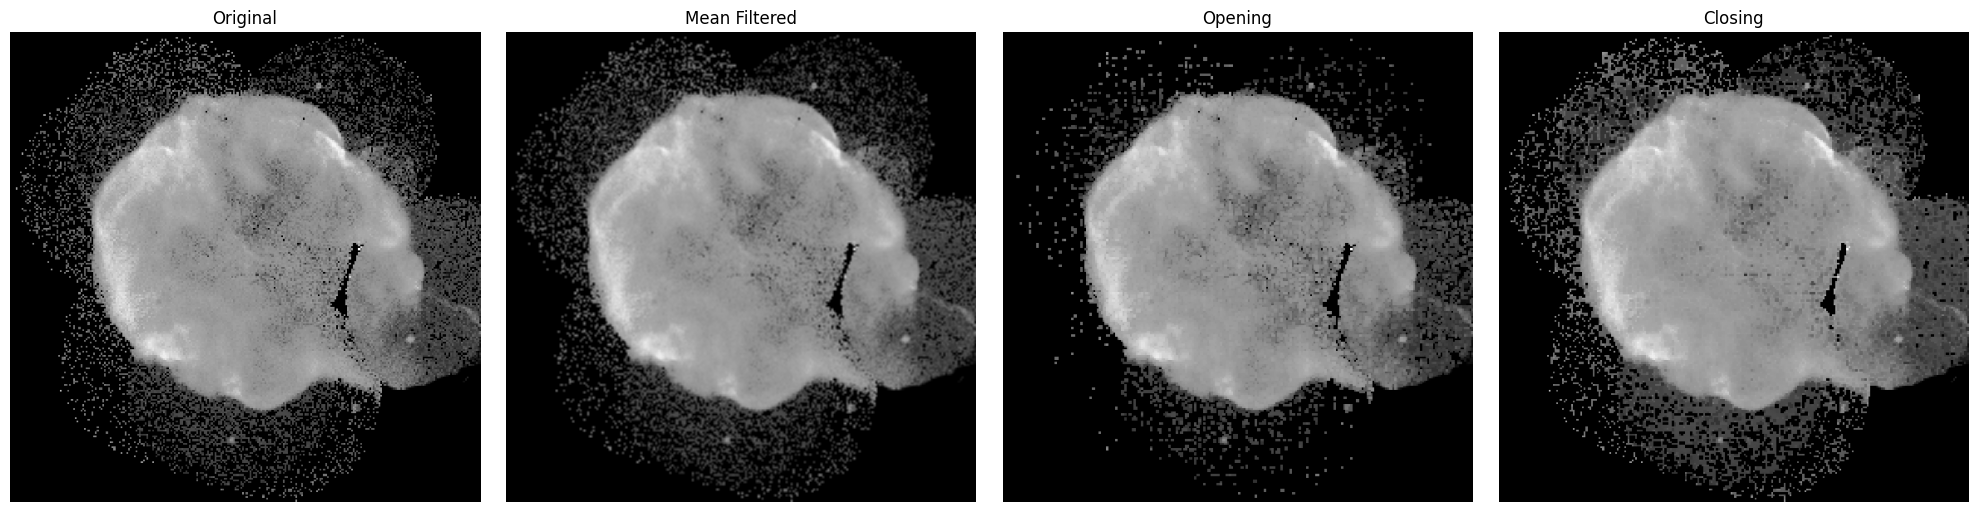

In [54]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0938(a)(cygnusloop_Xray_original).tif" -O xray.tif
img = cv2.imread('xray.tif', cv2.IMREAD_GRAYSCALE)

# 2. 평균 필터 (Smoothing)
mean_filtered = cv2.blur(img, (3, 3))

# 3. Morphological Opening (작은 점 노이즈 제거)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
morph_open = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

# 4. Morphological Closing (작은 구멍 채움)
morph_close = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

# 5. 결과
import matplotlib.pyplot as plt

titles = ['Original', 'Mean Filtered', 'Opening', 'Closing']
images = [img, mean_filtered, morph_open, morph_close]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 분석:
# - 평균 필터: 부드러워진 것 말고는 크게 차이가 느껴지지 않음
# - Opening: 퍼져있던 영역이 잘려나가면서 작은 점으로 분리됨
# - Closing: 잘려나간 영역들이 메워지고 더 대비가 강해진 느낌


# HW 2-9

--2025-04-13 05:02:23--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 360574 (352K) [image/tiff]
Saving to: ‘rice.tif’

rice.tif            100%[===================>] 352.12K  --.-KB/s    in 0.05s   

2025-04-13 05:02:23 (7.31 MB/s) - ‘rice.tif’ saved [360574/360574]



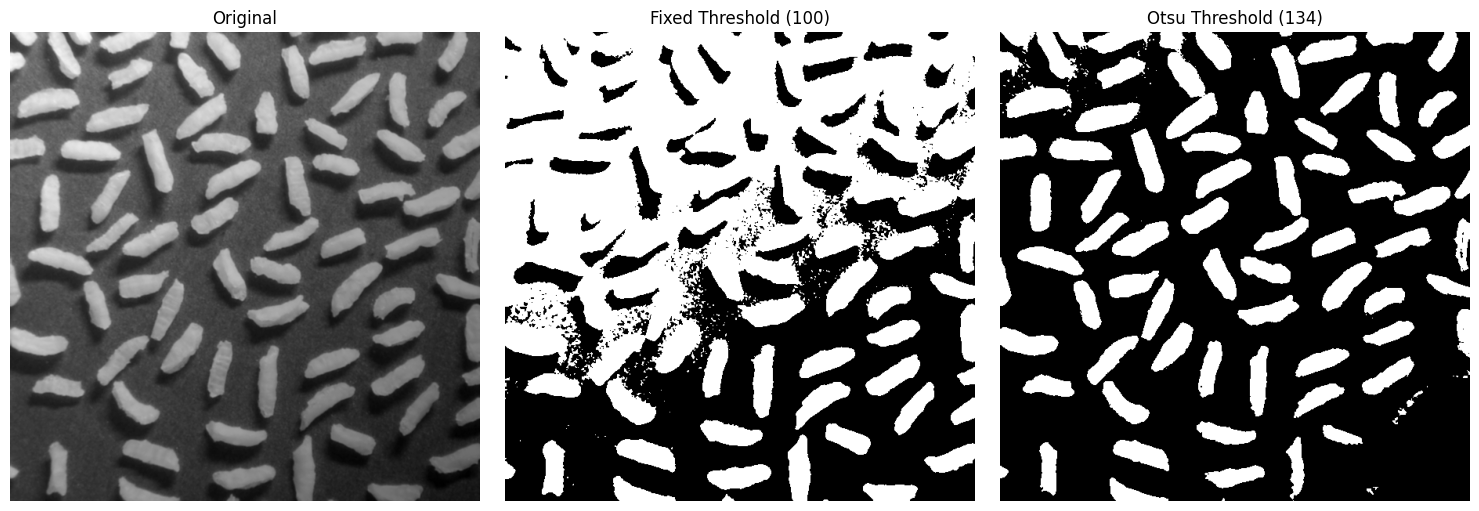

In [55]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif" -O rice.tif
img = cv2.imread('rice.tif', cv2.IMREAD_GRAYSCALE)

# 2. 고정 임계값 이진화 (threshold = 100)
_, binary_fixed = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

# 3. Otsu 이진화
_, binary_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. 결과
import matplotlib.pyplot as plt

titles = ['Original', 'Fixed Threshold (100)', f'Otsu Threshold ({int(_):d})']
images = [img, binary_fixed, binary_otsu]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 분석:
# - 고정 임계값은 전체 밝기 분포를 고려하지 않아 과하게 제거되는 문제가 발생함
# - Otsu는 히스토그램 기반 자동 임계값으로 배경과 객체 분리가 더 자연스럽게 이루어짐

# HW 2-10

--2025-04-13 05:02:24--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0943(a)(dark_blobs_on_light_background).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 360678 (352K) [image/tiff]
Saving to: ‘blob.tif’

blob.tif            100%[===================>] 352.22K  --.-KB/s    in 0.05s   

2025-04-13 05:02:24 (7.51 MB/s) - ‘blob.tif’ saved [360678/360678]



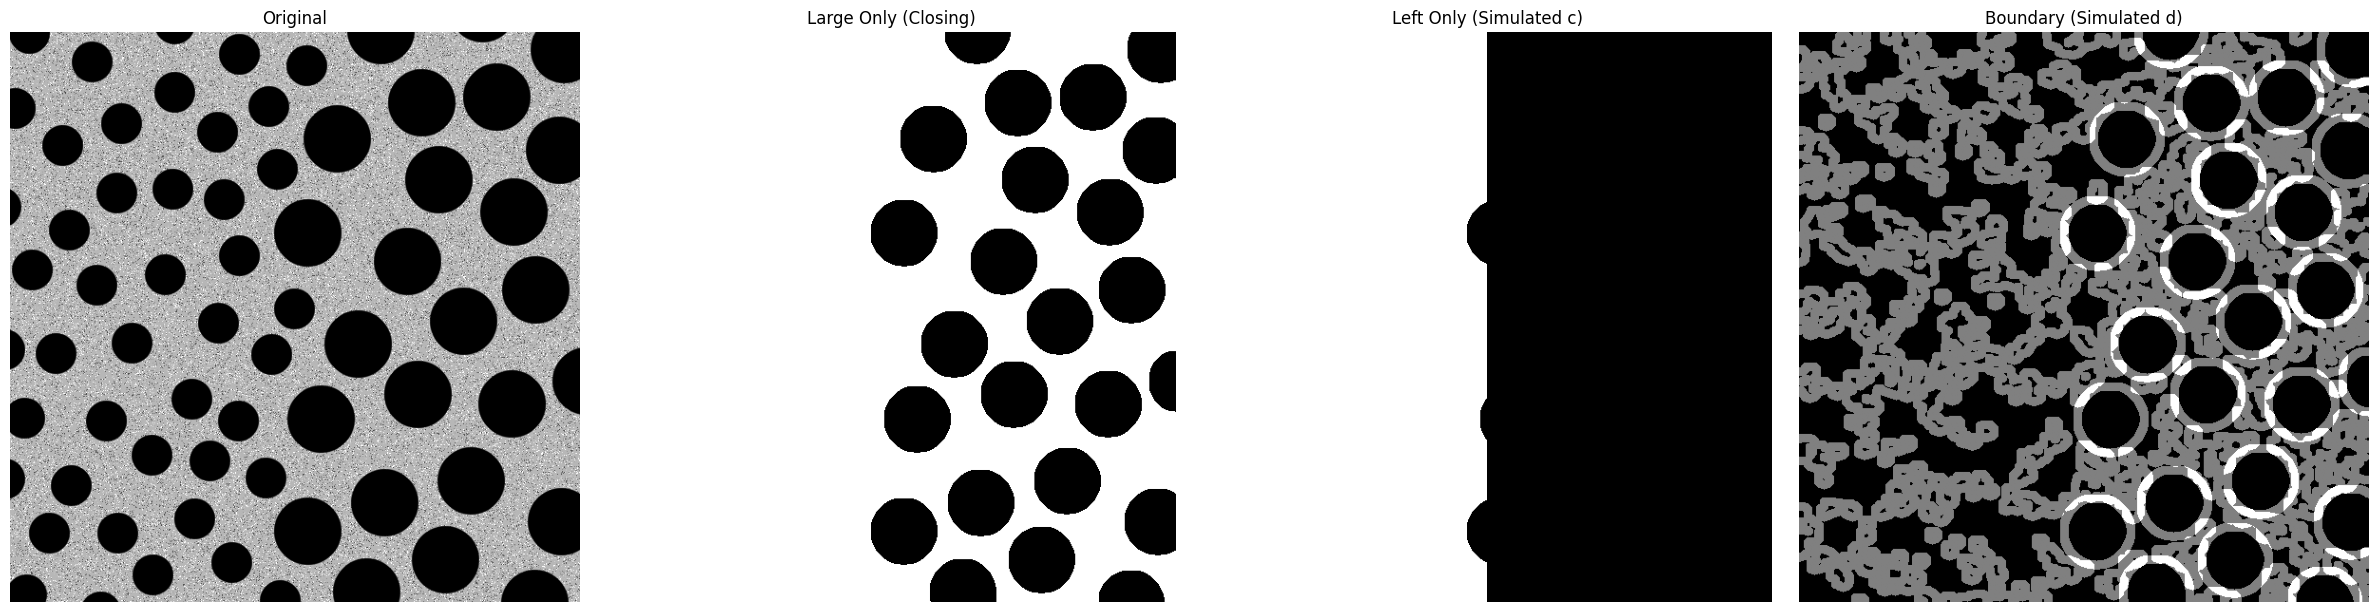

In [56]:
# 1. 영상
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0943(a)(dark_blobs_on_light_background).tif" -O blob.tif
img = cv2.imread('blob.tif', cv2.IMREAD_GRAYSCALE)

# 2. 이진화 (Otsu)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Closing (큰 원)
kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (50, 50))
large_only = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_large)

# 4. Opening (작은 원)
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))
small_only = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_small)

# 왼쪽 영역
height, width = img.shape
mask_left = np.zeros_like(img, dtype=np.uint8)
mask_left[:, :width // 2] = 1

left_only = cv2.bitwise_and(large_only, large_only, mask=mask_left)
seg_c = np.zeros_like(img)
seg_c[left_only == 255] = 128

# (d) -> 큰 원 + 작은 원 결합 후 경계만
mask_large = (large_only == 255).astype(np.uint8)
mask_small = (small_only == 255).astype(np.uint8)
combined = mask_large + mask_small
seg_d = cv2.morphologyEx((combined * 127).astype(np.uint8), cv2.MORPH_GRADIENT, kernel_small)

# 결과
import matplotlib.pyplot as plt

titles = ['Original', 'Large Only (Closing)', 'Left Only (Simulated c)', 'Boundary (Simulated d)']
images = [img, large_only, seg_c, seg_d]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for i in range(4):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 분석:
# - Closing 결과를 통해 큰 원만 분리하는 것은 해냄
# - (c), (d) 의 경우 정확히 재현하지 못했음
